---
title: "Sesi 1: Pengantar R, Pengolahan Data, dan Visualisasi"
subtitle: "ISEI Workshop: Analisis Regresi & SEM dengan RStudio"
jupyter: ir
execute:
  warning: false
  message: false
---

# Pengantar

Workshop ini mengikuti alur kerja data science: **Import → Tidy → Transform → Visualize → Model → Communicate** (Wickham & Grolemund, 2017).

![Alur kerja data science](images/data-workflow.png)

Workshop ini dirancang sebagai sesi **live-coding**. Tujuannya bukan hanya agar peserta bisa menyalin kode, tetapi juga memahami alur berpikir saat bekerja dengan data di R.

- Ikuti praktik secara bertahap sambil mencoba kode sendiri
- Jangan takut bereksperimen dan membuat error kecil
- Target sesi ini adalah membangun **fondasi** dan **kepercayaan diri** untuk belajar R secara mandiri

### Garis Besar Seri Workshop

1. **Impor** data ke R dari file atau sumber lain
2. **Rapikan (tidy)** data agar setiap kolom = variabel dan setiap baris = observasi
3. **Transformasi** data untuk filter, membuat variabel baru, dan menghitung ringkasan
4. **Visualisasi** dan **pemodelan** untuk memahami pola dan menguji hubungan
5. **Komunikasikan** hasil agar temuan dapat dipahami orang lain

### Rencana Hari Ini

- **Bagian 1**: Dasar-dasar R — objek, tipe data, vektor, faktor, dataframe
- **Bagian 2**: Pengolahan data dengan Tidyverse — import, filter, select, mutate, summarize
- **Bagian 3**: Visualisasi dan statistik deskriptif — ggplot2, histogram, boxplot, scatter plot, korelasi

---

## Apa itu R? Apa itu RStudio?

**R**: Bahasa pemrograman open-source yang dikembangkan untuk analisis statistik dan visualisasi. Komunitas R sangat aktif berbagi kode dan membuat paket-paket yang memperluas fungsionalitas R.

**RStudio**: Lingkungan pengembangan terintegrasi (IDE) yang memudahkan kita berinteraksi dengan R — menulis kode, menavigasi file, memeriksa variabel, dan memvisualisasikan plot.

- Anda perlu menginstal **keduanya**: R terlebih dahulu, baru kemudian RStudio.
- Kunjungi <https://posit.co/download/rstudio-desktop> untuk mengunduh.

R adalah **bahasanya**, sedangkan RStudio adalah **tempat bekerja** dengan bahasa tersebut. Dalam praktik sehari-hari, kita hampir selalu memakai keduanya secara berpasangan.

## Tur RStudio

Pertama, kita perlu familiar dengan antarmuka RStudio. Kita akan menggunakan RStudio untuk menulis kode, menavigasi file di komputer, memeriksa variabel yang kita buat, dan memvisualisasikan plot yang kita hasilkan.

![Tampilan R Studio](images/rstudio-tour.jpg){fig-align="center"}

### Sebelum Mulai Coding

1. **Working directory**: Folder tempat R mencari dan menyimpan file. Praktik terbaik: gunakan **R Project**.
2. **Buat proyek**: `File` > `New Project` > `New Directory` > `New Project`.
3. **Buat folder** di dalam proyek:
   - `data` — data mentah (jangan diubah!)
   - `data-output` — data yang sudah dimodifikasi
   - `fig-output` — grafik yang disimpan

Jika working directory tidak sesuai, ubah dari file browser di RStudio melalui menu **More → Set As Working Directory**.

::: {.callout-tip}
Jangan taruh proyek di folder OneDrive. Hindari spasi dan karakter khusus pada nama folder/file.
:::

Sebelum mulai menulis banyak kode, biasakan membuat **script R** baru melalui `File > New File > R Script`. Jalankan baris kode dari editor dengan shortcut `Ctrl + Enter` agar kode tersimpan dan mudah diulang.

### Penyegaran: Tipe Data Kuantitatif

**Data Non-Kontinu:**

- **Nominal/Kategorikal**: Data non-urut, non-numerik (contoh: kebangsaan, status pekerjaan)
- **Ordinal**: Data non-numerik berurutan (contoh: peringkat, frekuensi olahraga)
- **Diskrit**: Data numerik dengan nilai tertentu — biasanya bilangan bulat (contoh: ukuran sepatu)
- **Biner**: Data nominal dengan dua kemungkinan (contoh: ya/tidak, lulus/gagal)

**Data Kontinu:**

- **Interval**: Tidak memiliki "nol sejati" (contoh: suhu Celsius — 0°C bukan berarti tidak ada panas)
- **Rasio**: Memiliki "nol sejati" (contoh: pendapatan — 0 berarti tidak ada pendapatan)

---

# Bagian 1: Dasar-Dasar R

## 1. Objek dan Nilai

In [55]:
country_name <- "Singapore"

- `"Singapore"` adalah sebuah **nilai** (value)
- `country_name` adalah **objek** tempat kita menyimpan nilai
- `<-` adalah operator penugasan (assignment). Shortcut: `Alt` + `-` (Windows) atau `Option` + `-` (Mac)

Aturan penamaan objek: tidak boleh dimulai angka, case-sensitive, tidak boleh ada spasi, beberapa kata dicadangkan.

Anda juga bisa menggunakan `=`, tetapi dalam R, penulisan dengan `<-` adalah konvensi yang paling umum dan lebih mudah dikenali saat membaca script.

## 2. Tipe Data Dasar

R memiliki 4 tipe data dasar:

In [2]:
country_code <- "SGP"          # character
life_satisfaction <- 8.5        # numeric (double)
is_religious <- TRUE            # logical (boolean)
birth_year <- 1990L             # integer

typeof(country_code)
typeof(life_satisfaction)
typeof(is_religious)

[1] "logical"

- Untuk menyertakan komentar dalam kode, gunakan karakter `#`. Apa pun di sebelah kanan `#` diabaikan oleh R saat eksekusi.
- Praktik yang baik untuk membuat catatan dan menjelaskan kode.

Untuk memeriksa tipe data, kita bisa menggunakan `typeof()` atau `str()`. Fungsi `str()` berguna karena menampilkan **tipe data sekaligus isinya** secara ringkas.

### Operasi Aritmatika

In [3]:
(8 + 7 + 9) / 3    # rata-rata tiga skor
2025 - 1990         # hitung usia

[1] 35

### Operasi Boolean

In [4]:
life_satisfaction > 8                              # TRUE
country_code == "SGP"                              # TRUE
(country_code == "NZL") & (life_satisfaction > 8)  # AND: FALSE
(country_code == "NZL") | (life_satisfaction > 8)  # OR: TRUE

[1] TRUE

- Operator `&` berarti **kedua kondisi harus benar**
- Operator `|` berarti **minimal satu kondisi benar**

Operasi boolean sangat penting karena nantinya dipakai untuk **memfilter data**.

## 3. Fungsi

Fungsi mengambil input dan menghasilkan output. Nama fungsi selalu diikuti tanda kurung `()`.

Cara paling sederhana memahami fungsi adalah menganggapnya sebagai **resep**: fungsi menerima bahan (input), memprosesnya, lalu menghasilkan output.

In [5]:
round(3.1415926)             # default: 0 desimal
round(3.1415926, digits = 2) # argumen opsional

[1] 3.14

Gunakan `?round` di konsol untuk melihat dokumentasi fungsi.

- `3.1415926` adalah argumen yang dibutuhkan oleh fungsi `round()`
- `digits` adalah argumen opsional yang mengubah cara fungsi bekerja

Pola ini berlaku untuk hampir semua fungsi di R: ada argumen wajib, dan sering ada argumen tambahan untuk mengatur detail perilaku fungsi.

## Struktur Data di R

![](images/data-structures.svg){width=100% height=100%}

Kita akan mengeksplorasi 3 tipe dasar **struktur data** di R:

1. **Vektor** — dapat menampung beberapa nilai dalam satu objek
2. **Faktor** — struktur khusus untuk variabel kategorikal
3. **Dataframe** — struktur tabular (baris × kolom) untuk pemrosesan, plotting, dan statistik

Tipe lain (tidak dibahas): Lists, Matrices.

## 4. Vektor

Bayangkan vektor sebagai satu kolom dalam dataset. Vektor hanya bisa berisi 1 tipe data, dan dibuat dengan fungsi `c()`.

Vektor adalah struktur data paling dasar dan paling sering dipakai di R. Banyak operasi di R sebenarnya bekerja pada vektor, termasuk perhitungan, logika, dan indexing.

In [6]:
countries <- c("CAN", "NZL", "SGP", "CAN", "SGP")
satisfaction_scores <- c(8, 7, 9, 6, 8)

length(countries)
mean(satisfaction_scores)
sd(satisfaction_scores)

[1] 1.140175

### Mengakses Elemen Vektor

In [7]:
countries[1]              # elemen pertama
satisfaction_scores[1:3]  # elemen 1 sampai 3
satisfaction_scores[c(1, 3)]  # elemen 1 dan 3

[1] 8 9

Tanda kurung siku `[]` digunakan untuk **mengambil bagian tertentu dari data**, sedangkan tanda kurung bulat `()` digunakan untuk **menjalankan fungsi**.

### Filtering dengan Kondisi

In [8]:
criteria <- satisfaction_scores > 7
satisfaction_scores[criteria]

[1] 8 9 8

### Menangani Nilai NA

In [9]:
financial_satisfaction <- c(8, 7, NA, 6, 9, NA, 7)
mean(financial_satisfaction)                  # NA!
mean(financial_satisfaction, na.rm = TRUE)    # hapus NA dulu

[1] 7.4

## 5. Dataframe

Dataframe = struktur data tabular (baris × kolom), seperti spreadsheet.

Ini adalah struktur yang paling sering digunakan untuk analisis data, karena hampir semua dataset survei, eksperimen, dan administrasi dapat direpresentasikan sebagai tabel.

In [10]:
survey_data <- data.frame(
  country = c("SGP", "CAN", "NZL", "SGP", "CAN"),
  life_satisfaction = c(8, 7, 9, 6, 8),
  employment = c("Full time", "Student", "Part time", "Retired", "Full time")
)
survey_data

  country life_satisfaction
1     SGP                 8
2     CAN                 7
3     NZL                 9
4     SGP                 6
5     CAN                 8
  employment
1  Full time
2    Student
3  Part time
4    Retired
5  Full time

### Mengakses Kolom

In [11]:
survey_data$country       # sebagai vektor
survey_data["country"]    # sebagai dataframe
survey_data[1, 2]         # baris 1, kolom 2

[1] 8

## 6. Faktor

Faktor = struktur data untuk variabel kategorikal. Memiliki `levels` yang terurut.

Walaupun terlihat seperti teks biasa, faktor disimpan secara khusus oleh R agar kategori dapat diperlakukan secara benar dalam tabulasi, visualisasi, dan model statistik.

In [12]:
negara_factor <- factor(c("SGP", "CAN", "NZL", "SGP"))
levels(negara_factor)

[1] "CAN" "NZL" "SGP"

Faktor berurutan (ordinal):

In [13]:
pendidikan <- factor(c("SD", "SMA", "S1", "S2"),
                     levels = c("SD", "SMA", "S1", "S2"),
                     ordered = TRUE)
pendidikan

[1] SD  SMA S1  S2 
Levels: SD < SMA < S1 < S2

### Mengonversi Kolom Dataframe ke Faktor

Dalam praktik, kita sering perlu mengonversi kolom di dataframe ke faktor. Misalnya, kolom `negara` seharusnya berupa faktor karena berisi kategori, bukan teks bebas.

**Faktor tidak berurutan (nominal):**

In [14]:
# Contoh: konversi kolom negara dari character ke factor
negara_contoh <- c("Singapura", "Kanada", "Selandia Baru", "Singapura")
negara_contoh <- factor(negara_contoh)

# Periksa levels (R mengurutkan secara alfabet)
levels(negara_contoh)
str(negara_contoh)

 Factor w/ 3 levels "Kanada","Selandia Baru",..: 3 1 2 3


**Faktor berurutan (ordinal) — contoh dengan data survei:**

Sebagai contoh faktor berurutan, misalkan kita ingin mengurutkan `status_pekerjaan` dari yang paling tidak aktif ke paling aktif secara ekonomi:

In [15]:
status_contoh <- c("Penuh waktu", "Pelajar/Mahasiswa", "Paruh waktu", "Pensiunan", "Penuh waktu")
status_contoh <- factor(status_contoh,
                        levels = c("Tidak bekerja", "Pelajar/Mahasiswa",
                                   "Ibu rumah tangga", "Pensiunan",
                                   "Paruh waktu", "Penuh waktu",
                                   "Wiraswasta", "Lainnya"),
                        ordered = TRUE)

levels(status_contoh)
str(status_contoh)

 Ord.factor w/ 8 levels "Tidak bekerja"<..: 6 2 5 4 6


Dengan ordered factor, R memahami bahwa ada urutan antar kategori, sehingga operasi perbandingan (`>`, `<`) bisa dilakukan.

---

# Bagian 2: Pengolahan Data dengan Tidyverse

## 7. Muat Paket

In [16]:
library(tidyverse)
library(readxl)

── Attaching core tidyverse packages ─
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ─────────────────────────
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘ggplot2’ was built under R version 4.5.3 


`tidyverse` adalah kumpulan paket untuk data science: `dplyr` (manipulasi), `ggplot2` (visualisasi), `tidyr` (reshaping), dll.

- **Instalasi paket** biasanya cukup sekali saja: `install.packages("nama_paket")`
- **Memuat paket** perlu dilakukan setiap sesi R baru dengan `library(nama_paket)`

Dalam workshop ini, `tidyverse` dipakai sebagai toolkit utama karena sintaksnya konsisten dan relatif mudah dibaca.

### Mengapa Menggunakan Tidyverse?

- Kode terlihat lebih mirip bahasa Inggris sehingga lebih intuitif
- Tidyverse mengikuti pola sintaks yang konsisten
- Pesan error yang lebih jelas dan membantu

Contoh perbandingan:

```r
# Base R
subset_data <- data[data$usia > 18 & data$kepuasan_hidup > 5, c("negara", "usia")]

# Tidyverse  
subset_data <- data |> 
  filter(usia > 18, kepuasan_hidup > 5) |> 
  select(negara, usia)
```

Fungsi yang akan sering digunakan: `drop_na()`, `select()`, `filter()`, `mutate()`, `if_else()`, `case_when()`, `group_by()`, `summarize()`.

Cheatsheet berguna:

- [dplyr cheatsheet](https://rstudio.github.io/cheatsheets/html/data-transformation.html)
- [tidyr cheatsheet](https://rstudio.github.io/cheatsheets/html/tidyr.html)

## 8. Import Data

In [17]:
wvs1 <- read_excel("data/regresi/wvs1.xlsx")
wvs2 <- read_excel("data/regresi/wvs2.xlsx")

# Gabungkan kedua dataset
wvs <- bind_rows(wvs1, wvs2)
glimpse(wvs)

Rows: 13,799
Columns: 16
$ negara                 <chr> "Kana…
$ id_responden           <dbl> 12407…
$ pentingnya_keluarga    <dbl> 1, 1,…
$ pentingnya_teman       <dbl> 1, 1,…
$ pentingnya_waktu_luang <dbl> 1, 2,…
$ pentingnya_pekerjaan   <dbl> 1, 1,…
$ kebebasan_memilih      <dbl> 7, 5,…
$ kepuasan_hidup         <dbl> 5, 8,…
$ kepuasan_finansial     <dbl> 8, 2,…
$ religiusitas           <dbl> 9, 10…
$ skala_politik          <dbl> 10, 5…
$ jenis_kelamin          <chr> "Pere…
$ tahun_lahir            <dbl> 1944,…
$ usia                   <dbl> 76, 6…
$ status_pernikahan      <chr> "Pisa…
$ status_pekerjaan       <chr> "Pens…


### Fungsi Eksplorasi

In [18]:
dim(wvs)
names(wvs)

 [1] "negara"                
 [2] "id_responden"          
 [3] "pentingnya_keluarga"   
 [4] "pentingnya_teman"      
 [5] "pentingnya_waktu_luang"
 [6] "pentingnya_pekerjaan"  
 [7] "kebebasan_memilih"     
 [8] "kepuasan_hidup"        
 [9] "kepuasan_finansial"    
[10] "religiusitas"          
[11] "skala_politik"         
[12] "jenis_kelamin"         
[13] "tahun_lahir"           
[14] "usia"                  
[15] "status_pernikahan"     
[16] "status_pekerjaan"      

Fungsi-fungsi eksplorasi seperti `dim()`, `names()`, `str()`, `head()`, dan `tail()` berguna untuk memahami bentuk dataset sebelum mulai membersihkan atau menganalisisnya.

## 9. Operator Pipe (`|>`)

Pipe memungkinkan kita merangkai operasi tanpa membuat variabel perantara. Shortcut: `Ctrl`+`Shift`+`M`.

Pipe membuat alur kerja lebih mudah dibaca karena kita dapat menuliskan langkah transformasi dari atas ke bawah, mengikuti urutan logis proses analisis.

In [19]:
wvs_data <- wvs 

In [20]:
# Tanpa pipe
wvs_data <- drop_na(wvs_data)
wvs_sorted <- arrange(wvs_data, desc(usia))

In [21]:
# Dengan pipe
wvs_data |> 
  drop_na() |> 
  arrange(desc(usia))

# A tibble: 12,867 × 16
   negara        id_responden
   <chr>                <dbl>
 1 Kanada           124071434
 2 Selandia Baru    554070524
 3 Singapura        702070325
 4 Singapura        702070265
 5 Singapura        702070265
 6 Kanada           124071321
 7 Kanada           124073566
 8 Kanada           124074356
 9 Selandia Baru    554070216
10 Singapura        702070310
# ℹ 12,857 more rows
# ℹ 14 more variables:
#   pentingnya_keluarga <dbl>,
#   pentingnya_teman <dbl>,
#   pentingnya_waktu_luang <dbl>,
#   pentingnya_pekerjaan <dbl>,
#   kebebasan_memilih <dbl>, …
# ℹ Use `print(n = ...)` to see more rows

## 10. Data Wrangling

Bayangkan kita adalah asisten peneliti yang sedang menyiapkan data survei agar siap dianalisis. Langkah umum yang biasanya dilakukan adalah:

1. Menghapus nilai hilang
2. Menghapus duplikasi
3. Memilih variabel yang relevan
4. Menyaring observasi sesuai kriteria
5. Membuat variabel baru
6. Menyimpan hasil pembersihan

### Langkah 1: Hapus Nilai Kosong

In [22]:
wvs <- wvs |> drop_na()
dim(wvs)

[1] 12867    16

### Langkah 2: Hapus Duplikasi

In [23]:
wvs <- wvs |> distinct(id_responden, .keep_all = TRUE)

### Langkah 3: Pilih Kolom (select)

In [24]:
wvs <- wvs |>
  select(id_responden, negara, jenis_kelamin, tahun_lahir, usia,
         kepuasan_hidup, pentingnya_pekerjaan, kepuasan_finansial,
         kebebasan_memilih, religiusitas, skala_politik,
         status_pernikahan, status_pekerjaan)
glimpse(wvs)

Rows: 11,142
Columns: 13
$ id_responden         <dbl> 1240700…
$ negara               <chr> "Kanada…
$ jenis_kelamin        <chr> "Peremp…
$ tahun_lahir          <dbl> 1944, 1…
$ usia                 <dbl> 76, 69,…
$ kepuasan_hidup       <dbl> 5, 8, 9…
$ pentingnya_pekerjaan <dbl> 1, 1, 2…
$ kepuasan_finansial   <dbl> 8, 2, 8…
$ kebebasan_memilih    <dbl> 7, 5, 8…
$ religiusitas         <dbl> 9, 10, …
$ skala_politik        <dbl> 10, 5, …
$ status_pernikahan    <chr> "Pisah"…
$ status_pekerjaan     <chr> "Pensiu…


### Langkah 4: Filter dan Urutkan

In [25]:
wvs <- wvs |>
  filter(usia >= 18) |>
  arrange(desc(usia))

head(wvs)

# A tibble: 6 × 13
  id_responden negara    jenis_kelamin
         <dbl> <chr>     <chr>        
1    124071434 Kanada    Laki-laki    
2    554070524 Selandia… Perempuan    
3    702070325 Singapura Perempuan    
4    702070265 Singapura Laki-laki    
5    124071321 Kanada    Perempuan    
6    124073566 Kanada    Perempuan    
# ℹ 10 more variables:
#   tahun_lahir <dbl>, usia <dbl>,
#   kepuasan_hidup <dbl>,
#   pentingnya_pekerjaan <dbl>,
#   kepuasan_finansial <dbl>,
#   kebebasan_memilih <dbl>,
#   religiusitas <dbl>, …

### Langkah 5: Buat Variabel Baru (mutate + case_when)

In [26]:
wvs <- wvs |>
  mutate(kelompok_usia = case_when(
    usia <= 28 ~ "18-28",
    usia <= 44 ~ "29-44",
    usia <= 60 ~ "45-60",
    TRUE       ~ "61+"
  ))

wvs |>
  select(usia, kelompok_usia) |>
  head(4)

# A tibble: 4 × 2
   usia kelompok_usia
  <dbl> <chr>        
1    93 61+          
2    91 61+          
3    91 61+          
4    90 61+          

### Simpan Hasil

In [27]:
wvs |> write_csv("data-output/wvs_cleaned_v1.csv")

In [28]:
# Simpan ke excel
library(writexl)
wvs |> write_xlsx("data-output/wvs_cleaned_v1.xlsx")

### Konversi ke Factor

In [29]:
kolom_faktor <- c("negara", "jenis_kelamin", "status_pernikahan", "status_pekerjaan")

wvs_cleaned <- wvs |>
  mutate(across(all_of(kolom_faktor), as_factor))

str(wvs_cleaned[kolom_faktor])

tibble [11,142 × 4] (S3: tbl_df/tbl/data.frame)
 $ negara           : Factor w/ 5 levels "Kanada","Selandia Baru",..: 1 2 3 3 1 1 1 2 3 3 ...
 $ jenis_kelamin    : Factor w/ 3 levels "Laki-laki","Perempuan",..: 1 2 2 1 2 2 1 2 2 1 ...
 $ status_pernikahan: Factor w/ 6 levels "Janda/Duda","Lajang",..: 1 1 1 1 1 2 3 1 4 1 ...
 $ status_pekerjaan : Factor w/ 8 levels "Paruh waktu",..: 1 2 2 2 2 2 2 2 2 2 ...


## 11. Group By + Summarize

Tujuan ringkasan deskriptif adalah mengubah data mentah menjadi informasi yang lebih ringkas. Dalam praktiknya, kita sering ingin menghitung rata-rata, simpangan baku, atau jumlah observasi **per kelompok**.

In [30]:
wvs_cleaned |>
  summarize(
    rata_rata = mean(kepuasan_hidup),
    sd = sd(kepuasan_hidup),
    n = n(),
    .by = negara
  )

# A tibble: 5 × 4
  negara        rata_rata    sd     n
  <fct>             <dbl> <dbl> <int>
1 Kanada             7.04  1.81  4018
2 Selandia Baru      7.60  1.79   660
3 Singapura          6.99  1.84  1972
4 Indonesia          7.54  2.44  3156
5 Thailand           6.56  2.20  1336

Fungsi `summarize()` menghitung ringkasan statistik per grup yang ditentukan oleh `.by`. Di sini kita mendapat rata-rata, SD, dan jumlah observasi kepuasan hidup untuk setiap negara. Selandia Baru memiliki rata-rata tertinggi (7.60), Thailand terendah (6.56).

### Grup Kepuasan: if_else

In [31]:
wvs_cleaned <- wvs_cleaned |>
  mutate(
    grup_kepuasan = if_else(
      kepuasan_hidup > mean(kepuasan_hidup),
      "Di Atas Rata-rata",
      "Di Bawah Rata-rata"
    )
  )

table(wvs_cleaned$negara, wvs_cleaned$grup_kepuasan)

               
                Di Atas Rata-rata
  Kanada                     1878
  Selandia Baru               423
  Singapura                   824
  Indonesia                  1850
  Thailand                    496
               
                Di Bawah Rata-rata
  Kanada                      2140
  Selandia Baru                237
  Singapura                   1148
  Indonesia                   1306
  Thailand                     840

Fungsi `if_else()` membuat variabel baru dengan dua kemungkinan nilai berdasarkan kondisi. `table()` lalu menampilkan tabulasi silang antara `negara` dan `grup_kepuasan`. Hasilnya menunjukkan frekuensi responden "Di Atas" vs "Di Bawah" rata-rata per negara.

Fungsi `if_else()` cocok untuk aturan sederhana dengan dua hasil, sedangkan `case_when()` lebih cocok jika kita punya banyak kondisi seperti pada pembuatan `kelompok_usia`.

### Pivot: Reshape Data

In [32]:
wvs_cleaned |>
  summarize(
    rata_kepuasan = mean(kepuasan_hidup),
    .by = c(negara, kelompok_usia)
  ) |>
  pivot_wider(
    names_from = kelompok_usia,
    values_from = rata_kepuasan
  )

# A tibble: 5 × 5
  negara `61+` `45-60` `29-44` `18-28`
  <fct>  <dbl>   <dbl>   <dbl>   <dbl>
1 Kanada  7.55    6.92    6.99    6.60
2 Selan…  7.96    7.38    7.32    6.70
3 Singa…  7.18    7.01    6.98    6.62
4 Indon…  7.40    7.46    7.56    7.68
5 Thail…  6.81    6.55    6.53    6.37

Fungsi `pivot_wider()` mengubah data dari format "panjang" ke "lebar" — kolom `kelompok_usia` menjadi nama kolom baru, dan nilainya diisi oleh `rata_kepuasan`. Hasilnya lebih mudah dibaca untuk perbandingan antar kelompok usia per negara.

### Latihan Tidyverse

Muat file `data/regresi/wvs2.xlsx`, gabungkan dengan `wvs_data` menggunakan `bind_rows()`. Saring hanya responden dari Indonesia, lalu hitung rata-rata `kepuasan_hidup` per `jenis_kelamin`.

In [33]:
#| code-fold: true
#| code-summary: "Jawaban"
wvs2_latihan <- read_excel("data/regresi/wvs2.xlsx")
wvs_gabungan <- bind_rows(wvs_data, wvs2_latihan)

wvs_gabungan |>
  filter(negara == "Indonesia") |>
  summarize(
    rata_kepuasan = mean(kepuasan_hidup, na.rm = TRUE),
    n = n(),
    .by = jenis_kelamin
  )

# A tibble: 2 × 3
  jenis_kelamin rata_kepuasan     n
  <chr>                 <dbl> <int>
1 Laki-laki              7.37  2877
2 Perempuan              7.69  3479

---

# Bagian 3: Visualisasi dan Statistik Deskriptif

## 12. Statistik Deskriptif

### Ukuran Pemusatan

In [34]:
library(DescTools)
mean(wvs_cleaned$usia, na.rm = TRUE)
median(wvs_cleaned$usia, na.rm = TRUE)
DescTools::Mode(wvs_cleaned$usia, na.rm = TRUE)

Warning message:
package ‘DescTools’ was built under R version 4.5.3 


[1] 38
attr(,"freq")
[1] 276

### Ukuran Penyebaran

In [35]:
sd(wvs_cleaned$usia, na.rm = TRUE)
var(wvs_cleaned$usia, na.rm = TRUE)
range(wvs_cleaned$usia, na.rm = TRUE)
IQR(wvs_cleaned$usia, na.rm = TRUE)

[1] 25

### Ringkasan per Variabel

In [36]:
wvs_cleaned |>
  select(kepuasan_hidup, kebebasan_memilih, kepuasan_finansial, usia) |>
  pivot_longer(everything(), names_to = "variabel", values_to = "nilai") |>
  summarize(
    M = mean(nilai), SD = sd(nilai),
    Min = min(nilai), Max = max(nilai),
    .by = variabel
  )

# A tibble: 4 × 5
  variabel         M    SD   Min   Max
  <chr>        <dbl> <dbl> <dbl> <dbl>
1 kepuasan_hi…  7.15  2.08    -2    10
2 kebebasan_m…  7.23  2.16    -2    10
3 kepuasan_fi…  6.49  2.36    -2    10
4 usia         45.5  15.9     18    93

Kombinasi `pivot_longer()` + `summarize()` dipakai untuk menghitung statistik deskriptif (M, SD, Min, Max) sekaligus untuk beberapa variabel numerik. Ini cara efisien menghindari penulisan `mean()`, `sd()` berulang per variabel.

### Tabel Frekuensi

In [37]:
table(wvs_cleaned$negara)


       Kanada Selandia Baru 
         4018           660 
    Singapura     Indonesia 
         1972          3156 
     Thailand 
         1336 

Fungsi `table()` menghitung frekuensi setiap level dalam variabel faktor. Output menunjukkan jumlah responden per negara — Kanada paling banyak (4.018), Selandia Baru paling sedikit (660).

## 13. Pengantar ggplot2

`ggplot2` adalah sistem visualisasi data berbasis **"Grammar of Graphics"** — setiap plot dibangun dari **layers** (lapisan) yang ditumpuk satu per satu.

Struktur dasar:

```r
ggplot(data, aes(x = var_x, y = var_y)) +
  geom_tipe_plot()
```

Komponen utama:

| Komponen | Fungsi |
|----------|--------|
| `ggplot()` | Inisialisasi plot dengan data |
| `aes()` | Pemetaan variabel ke estetika visual (x, y, warna, ukuran, dll.) |
| `geom_*()` | Tipe geometri plot (titik, garis, bar, histogram, dll.) |
| `labs()` | Label dan judul |
| `theme_*()` | Tema tampilan |
| `facet_wrap()` | Membagi plot berdasarkan variabel kategorikal |

Karena dibangun secara berlapis, kita bisa mulai dari plot sederhana lalu menambahkan elemen sedikit demi sedikit sampai visualisasi menjadi informatif.

## 14. Visualisasi

### Histogram

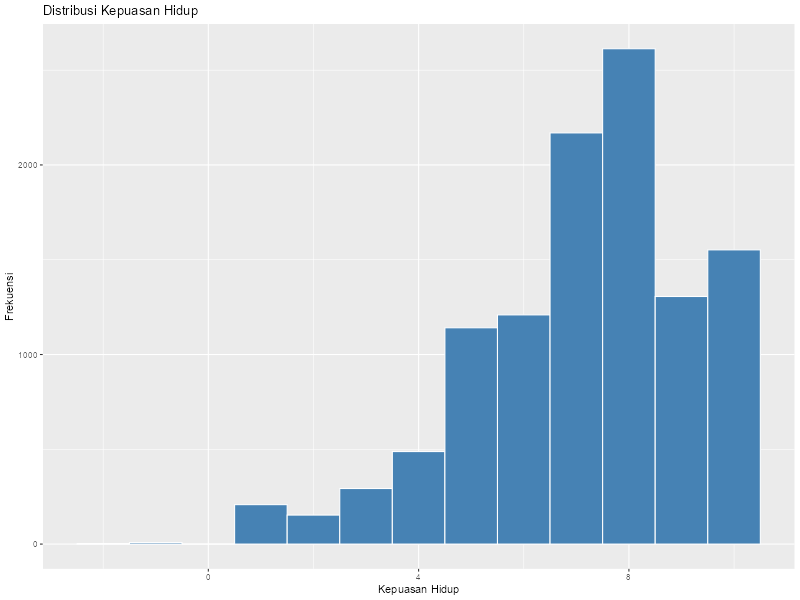

In [38]:
ggplot(wvs_cleaned, aes(x = kepuasan_hidup)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(title = "Distribusi Kepuasan Hidup", x = "Kepuasan Hidup", y = "Frekuensi")

`geom_histogram()` menampilkan distribusi frekuensi variabel numerik. Parameter `binwidth = 1` mengatur lebar setiap batang = 1 unit. Distribusi kepuasan hidup tampak miring ke kiri (negatively skewed) — mayoritas responden melaporkan skor 7–8.

### Boxplot per Negara

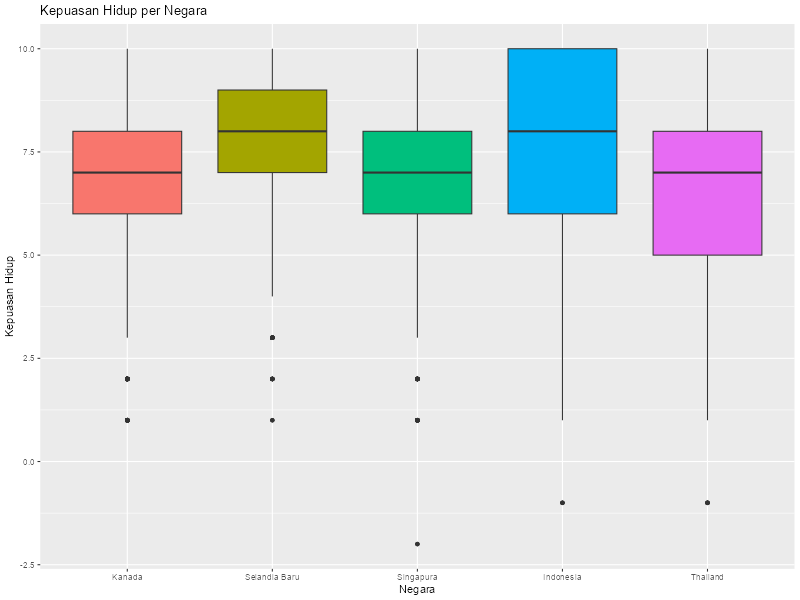

In [39]:
ggplot(wvs_cleaned, aes(x = negara, y = kepuasan_hidup, fill = negara)) +
  geom_boxplot() +
  labs(title = "Kepuasan Hidup per Negara", x = "Negara", y = "Kepuasan Hidup") +
  theme(legend.position = "none")

`geom_boxplot()` menampilkan distribusi variabel numerik per kategori: median (garis tengah), IQR (kotak), dan outlier (titik). Argumen `fill = negara` memberi warna berbeda per negara. Selandia Baru memiliki median tertinggi; Indonesia memiliki IQR paling lebar.

### Bar Chart

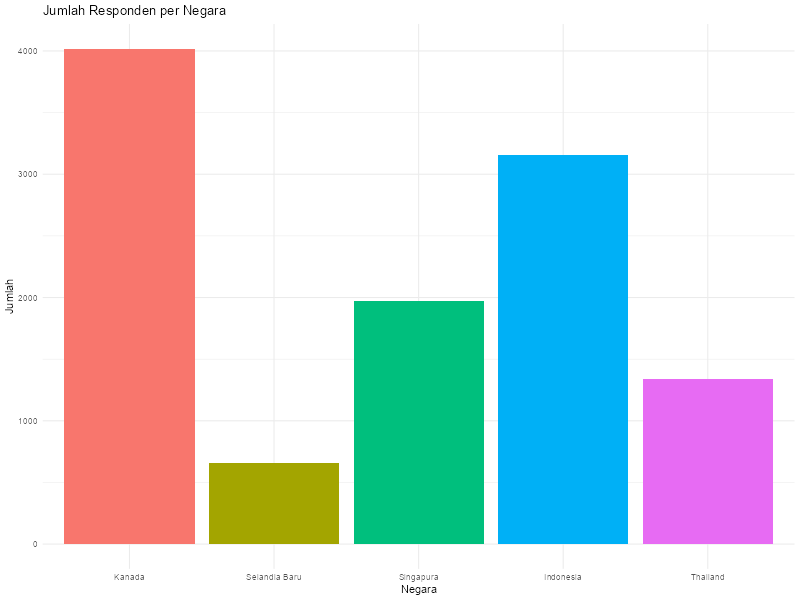

In [40]:
ggplot(wvs_cleaned, aes(x = negara, fill = negara)) +
  geom_bar() +
  labs(title = "Jumlah Responden per Negara", x = "Negara", y = "Jumlah") +
  theme_minimal() +
  theme(legend.position = "none")

### Pie Chart

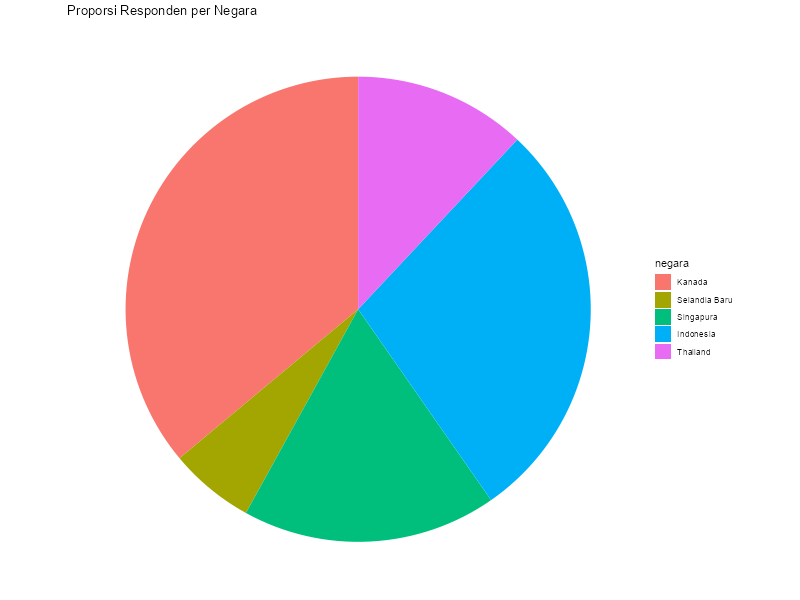

In [41]:
proporsi_negara <- wvs_cleaned |>
  count(negara) |>
  mutate(persen = n / sum(n) * 100)

ggplot(proporsi_negara, aes(x = "", y = persen, fill = negara)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  labs(title = "Proporsi Responden per Negara") +
  theme_void()

### Scatter Plot

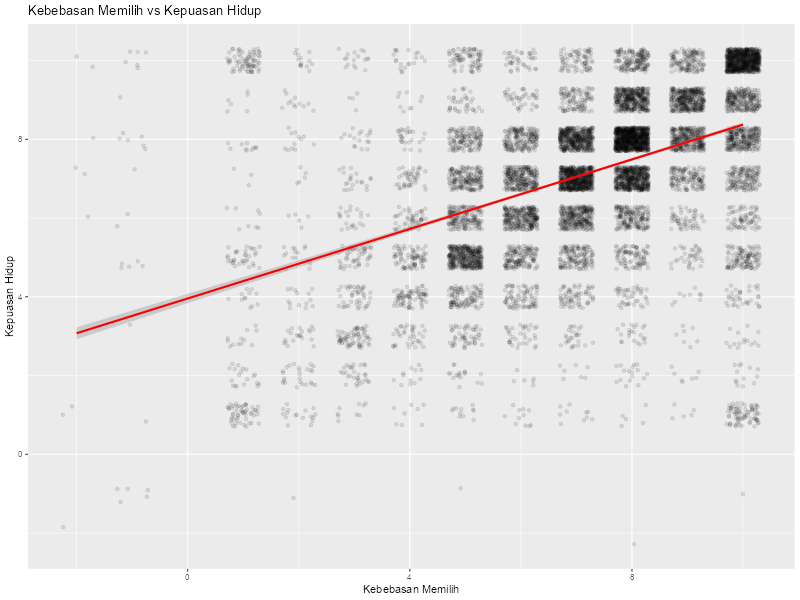

`geom_smooth()` using formula = 'y ~
x'

In [42]:
ggplot(wvs_cleaned, aes(x = kebebasan_memilih, y = kepuasan_hidup)) +
  geom_jitter(alpha = 0.1, width = 0.3, height = 0.3) +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Kebebasan Memilih vs Kepuasan Hidup",
       x = "Kebebasan Memilih", y = "Kepuasan Hidup")

`geom_jitter()` menyebarkan titik data agar tidak menumpuk (karena skala diskrit), dan `geom_smooth(method = "lm")` menambahkan garis regresi linear. Pola menunjukkan hubungan positif: semakin tinggi kebebasan memilih, semakin tinggi kepuasan hidup.

### Latihan: Histogram

Buat histogram `kepuasan_finansial` dengan `binwidth = 1`.

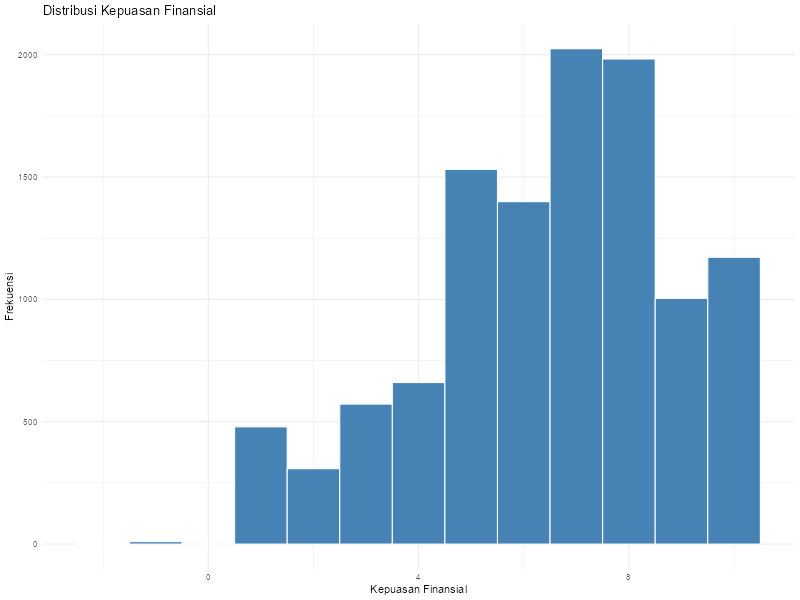

In [43]:
#| code-fold: true
#| code-summary: "Jawaban"
ggplot(wvs_cleaned, aes(x = kepuasan_finansial)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(title = "Distribusi Kepuasan Finansial",
       x = "Kepuasan Finansial", y = "Frekuensi") +
  theme_minimal()

### Tabulasi Silang

Tabulasi silang membantu kita melihat distribusi bersama dari dua variabel kategorikal. Ini berguna sebelum membuat stacked bar chart atau grouped bar chart.

In [44]:
wvs_cleaned |>
  count(negara, kelompok_usia) |>
  pivot_wider(names_from = negara, values_from = n)

# A tibble: 4 × 6
  kelompok_usia Kanada `Selandia Baru`
  <chr>          <int>           <int>
1 18-28            712              27
2 29-44           1232             119
3 45-60           1061             222
4 61+             1013             292
# ℹ 3 more variables:
#   Singapura <int>, Indonesia <int>,
#   Thailand <int>

### Stacked Bar Chart

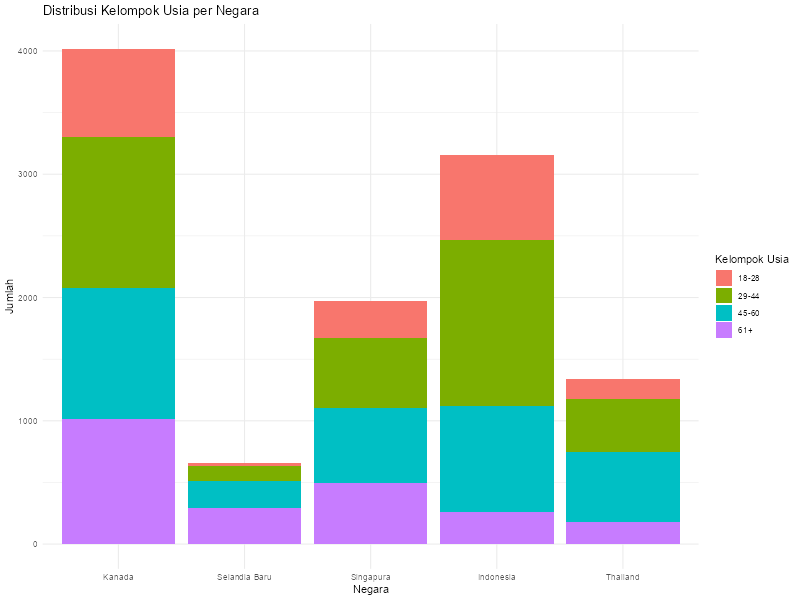

In [45]:
ggplot(wvs_cleaned, aes(x = negara, fill = kelompok_usia)) +
  geom_bar() +
  labs(title = "Distribusi Kelompok Usia per Negara",
       x = "Negara", y = "Jumlah", fill = "Kelompok Usia") +
  theme_minimal()

### Grouped Bar Chart

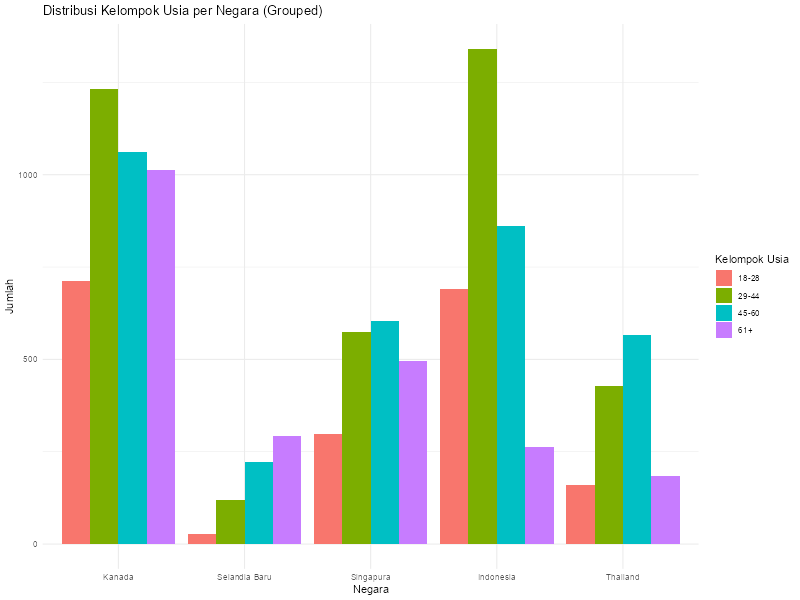

In [46]:
ggplot(wvs_cleaned, aes(x = negara, fill = kelompok_usia)) +
  geom_bar(position = "dodge") +
  labs(title = "Distribusi Kelompok Usia per Negara (Grouped)",
       x = "Negara", y = "Jumlah", fill = "Kelompok Usia") +
  theme_minimal()

### Proportional Bar Chart

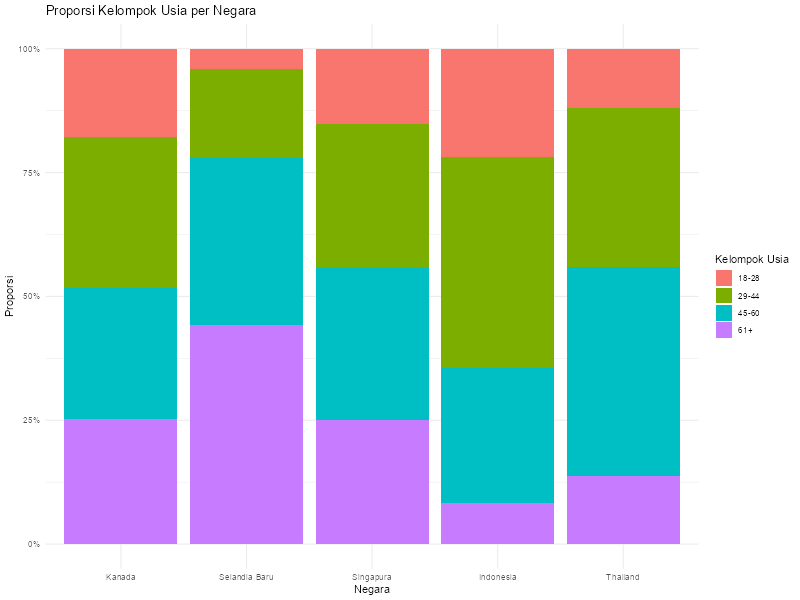

In [47]:
ggplot(wvs_cleaned, aes(x = negara, fill = kelompok_usia)) +
  geom_bar(position = "fill") +
  labs(title = "Proporsi Kelompok Usia per Negara",
       x = "Negara", y = "Proporsi", fill = "Kelompok Usia") +
  theme_minimal() +
  scale_y_continuous(labels = scales::percent)

## 15. Korelasi

In [48]:
cor(wvs_cleaned$kepuasan_finansial, wvs_cleaned$kepuasan_hidup)

[1] 0.5705897

Fungsi `cor()` menghitung korelasi Pearson antara dua variabel numerik. Nilai r = 0.57 menunjukkan hubungan positif moderat–kuat antara kepuasan finansial dan kepuasan hidup.

### Matriks Korelasi

corrplot 0.95 loaded


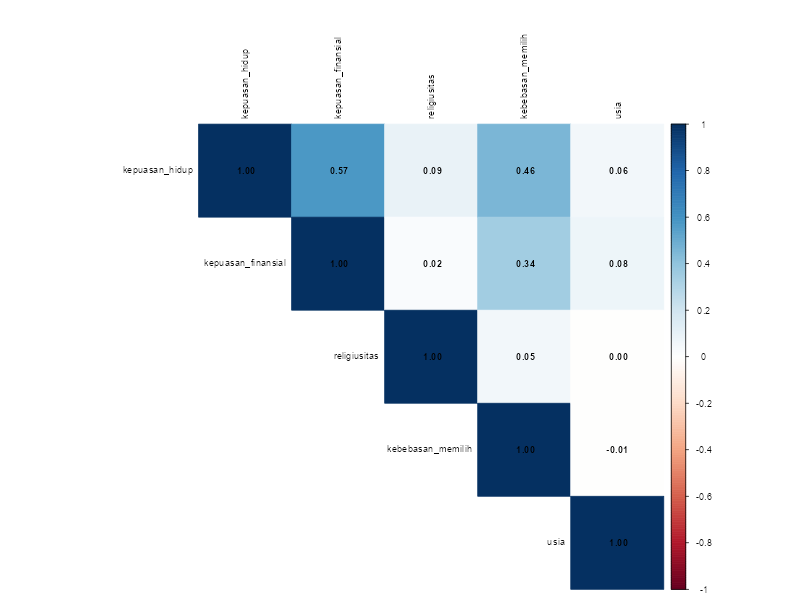

In [49]:
library(corrplot)

wvs_cleaned |>
  select(kepuasan_hidup, kepuasan_finansial, religiusitas,
         kebebasan_memilih, usia) |>
  cor(use = "complete.obs") |>
  corrplot(method = "color", type = "upper",
           addCoef.col = "black", number.cex = 0.8,
           tl.col = "black", tl.cex = 0.8)

Fungsi `corrplot()` memvisualisasikan matriks korelasi. Warna biru tua = korelasi positif kuat, merah = negatif. Korelasi terkuat: kepuasan finansial–kepuasan hidup (0.57). Religiusitas dan usia nyaris tidak berkorelasi dengan variabel lain.

## 16. Faceting

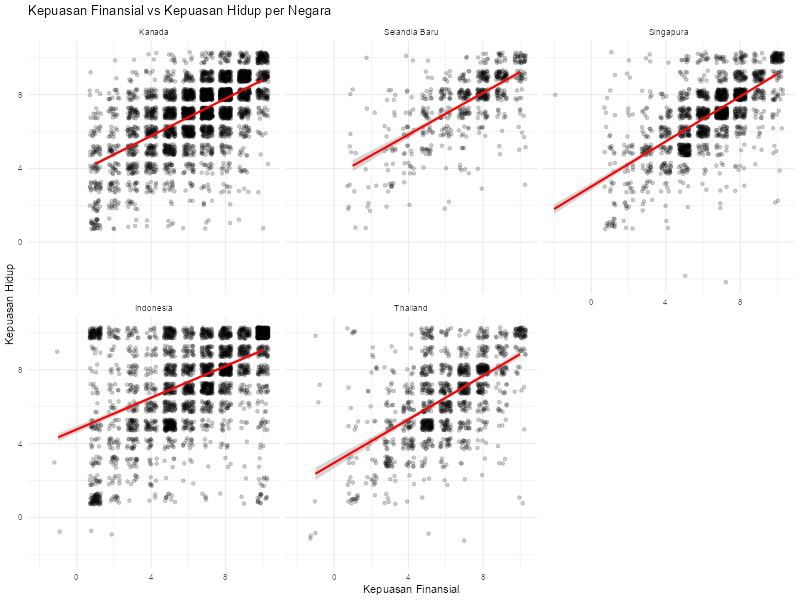

`geom_smooth()` using formula = 'y ~
x'

In [50]:
ggplot(wvs_cleaned, aes(x = kepuasan_finansial, y = kepuasan_hidup)) +
  geom_jitter(alpha = 0.2, width = 0.3, height = 0.3) +
  geom_smooth(method = "lm", color = "red") +
  facet_wrap(~ negara) +
  labs(title = "Kepuasan Finansial vs Kepuasan Hidup per Negara",
       x = "Kepuasan Finansial", y = "Kepuasan Hidup") +
  theme_minimal()

`facet_wrap(~ negara)` memecah satu plot menjadi panel terpisah berdasarkan variabel kategorikal. Ini memudahkan perbandingan pola hubungan kepuasan finansial–kepuasan hidup antar negara. Slope positif konsisten di semua negara.

### Menyimpan Plot

Setelah membuat plot yang rapi, simpan hasilnya dengan `ggsave()` agar dapat digunakan dalam laporan, slide, atau artikel.

```r
p <- ggplot(wvs_cleaned, aes(x = kepuasan_finansial, y = kepuasan_hidup)) +
  geom_jitter(alpha = 0.2) +
  geom_smooth(method = "lm") +
  theme_minimal()

ggsave("output/scatter_kepuasan.png", plot = p, width = 8, height = 6, dpi = 300)
```

---

# Troubleshooting

Jenis pesan di R:

- **Error**: Kesalahan fatal — kode gagal dijalankan. Harus diperbaiki.
- **Warning**: Pesan peringatan — kode tetap berjalan tetapi ada potensi masalah.
- **Message**: Informasi — biasanya bisa diabaikan.

Checklist jika kode error:

- Sudah mengatur working directory?
- Cek koma (`,`) dan tanda kurung `()` yang hilang?
- Cek ejaan? (R peka huruf besar/kecil!)
- Cek tanda kutip `""` dan operator?

Kesalahan kecil seperti kapitalisasi (`sum` vs `sUm`), tanda baca yang kurang, atau salah menaruh tanda kutip sering menjadi penyebab error paling umum bagi pemula.

---

# Rekap Sesi 1

- **Dasar R**: objek, tipe data (character, numeric, logical, integer), vektor, faktor, dataframe
- **Tidyverse**: `select()`, `filter()`, `mutate()`, `case_when()`, `group_by()`, `summarize()`, `pivot_wider()`, operator pipe `|>`
- **Visualisasi**: histogram, boxplot, bar chart, pie chart, scatter plot, faceting, matriks korelasi
- **Statistik Deskriptif**: mean, median, mode, sd, var, range, IQR, tabulasi frekuensi

---

# Latihan

## Latihan 1

Buat boxplot `kepuasan_finansial` per `jenis_kelamin`.

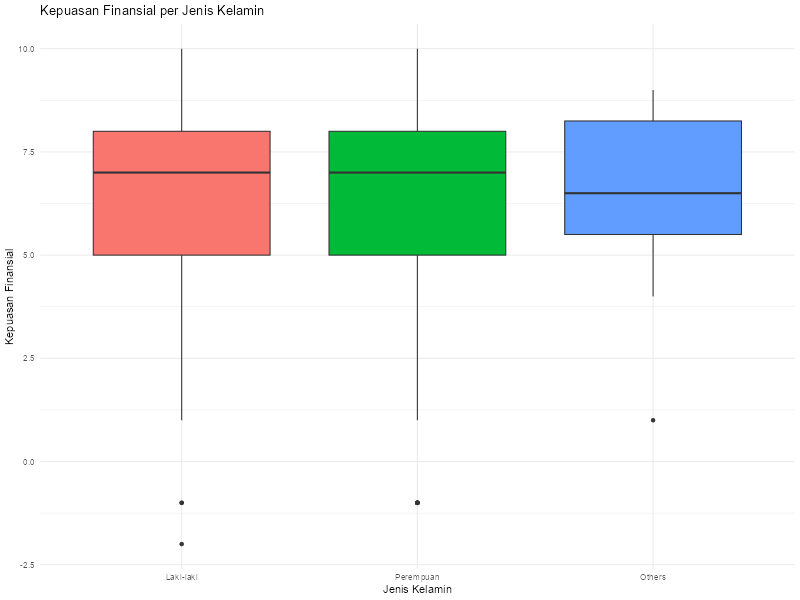

In [51]:
#| code-fold: true
#| code-summary: "Jawaban"
ggplot(wvs_cleaned, aes(x = jenis_kelamin, y = kepuasan_finansial,
                        fill = jenis_kelamin)) +
  geom_boxplot() +
  labs(title = "Kepuasan Finansial per Jenis Kelamin",
       x = "Jenis Kelamin", y = "Kepuasan Finansial") +
  theme_minimal() +
  theme(legend.position = "none")

## Latihan 2

Hitung rata-rata `kebebasan_memilih` per `negara` dan `jenis_kelamin`.

In [52]:
#| code-fold: true
#| code-summary: "Jawaban"
wvs_cleaned |>
  summarize(
    rata_kebebasan = mean(kebebasan_memilih, na.rm = TRUE),
    n = n(),
    .by = c(negara, jenis_kelamin)
  )

# A tibble: 11 × 4
   negara jenis_kelamin rata_kebebasan
   <fct>  <fct>                  <dbl>
 1 Kanada Laki-laki               7.41
 2 Selan… Perempuan               7.74
 3 Singa… Perempuan               6.86
 4 Singa… Laki-laki               6.75
 5 Kanada Perempuan               7.45
 6 Selan… Laki-laki               7.74
 7 Indon… Laki-laki               7.66
 8 Indon… Perempuan               7.60
 9 Thail… Perempuan               6.16
10 Thail… Laki-laki               5.96
11 Thail… Others                  5.5 
# ℹ 1 more variable: n <int>

## Latihan 3

Buat boxplot `kepuasan_finansial` per `jenis_kelamin`, dengan facet per `negara`.

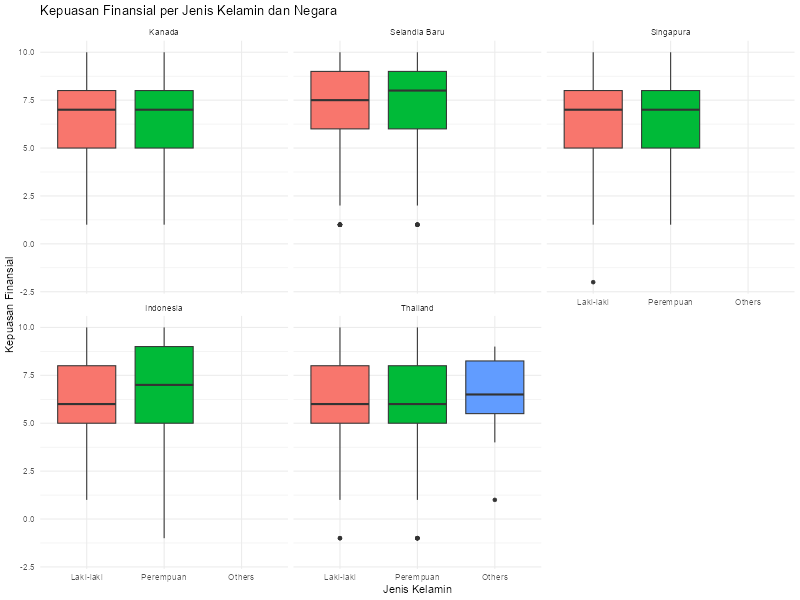

In [53]:
#| code-fold: true
#| code-summary: "Jawaban"
ggplot(wvs_cleaned, aes(x = jenis_kelamin, y = kepuasan_finansial,
                        fill = jenis_kelamin)) +
  geom_boxplot() +
  facet_wrap(~ negara) +
  labs(title = "Kepuasan Finansial per Jenis Kelamin dan Negara",
       x = "Jenis Kelamin", y = "Kepuasan Finansial") +
  theme_minimal() +
  theme(legend.position = "none")